<center><img src="mmu.png"/></center>

<h2><center>TDW 3311 Data Wrangling and Visualisation</center></h2>
<h2><center>Lab 09 - Interactive Visualisation</center></h2>

This lab introduces graphical representations of analyzed data (static or dynamic) that can react and respond to user
actions in the moment. They are static visualisations that incorporate features to accept human inputs, thus enhancing
and increasing the impact that data has.

<center><img src="visual.png"/></center>

Interactive visualisations are often also built on dynamic data that constantly change in real time. An example of interactive data visualisation with dynamic data is the visualisation depicting fluctuations in stock trends. 

In this lab, we will create interactive plots using Altair scatter plot and heatmap:
-  Scatter plot: shows the relationship between two variables in a dataset, for example, weather vs sales, salary vs car price, etc.
-  Heatmap: visualises high-dimensional continuous numerical features that are particularly changing across different classes. Each cell in the grid corresponds to a specific pair of values taken by the two discrete features and is colored based on the value of the third numerical feature.

## Task 1: Plotting and interacting with a scatter plot

1. Read the dataset using Pandas.

In [2]:
import pandas as pd
%matplotlib inline

hpi_url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/hpi_data_countries.tsv"

# Read the dataset into a DataFrame using Pandas
hpi_df = pd.read_csv(hpi_url, sep='\t')

# View the fields and first 5 records of the dataset.
hpi_df.head()

,HPI Rank,Country,Region,Life Expectancy (years),Wellbeing (0-10),Inequality of outcomes,Ecological Footprint (gha/capita),Happy Planet Index
0,1,Costa Rica,Americas,79.1,7.3,15%,2.8,44.7
1,2,Mexico,Americas,76.4,7.3,19%,2.9,40.7
2,3,Colombia,Americas,73.7,6.4,24%,1.9,40.7
3,4,Vanuatu,Asia Pacific,71.3,6.5,22%,1.9,40.6
4,5,Vietnam,Asia Pacific,75.5,5.5,19%,1.7,40.3


2.  Plot a static scatter plot using Seaborn. Try to describe the scatter plot.

Each dot here represents a country from one of the 7 regions. Wellbeing and Happy Planet Index appear to be correlated.


<Axes: xlabel='Wellbeing (0-10)', ylabel='Happy Planet Index'>

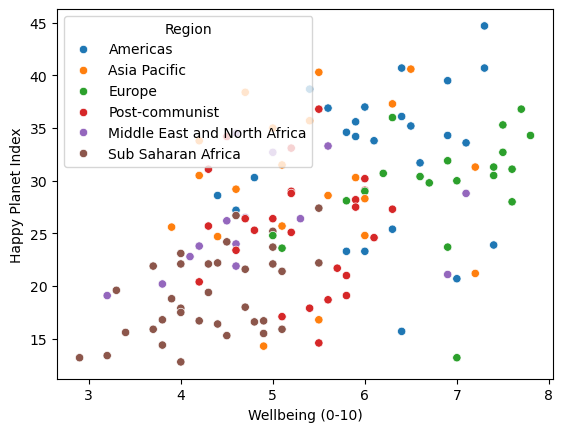

In [5]:
import seaborn as sns

sns.scatterplot(x='Wellbeing (0-10)', y='Happy Planet Index', hue='Region', data=hpi_df)


3. Use the mark_circle() function from the <b>altair</b> module to present data points in the scatter plot using filled circles. Use the interactive function to make the plot interactive, e.g., with zooming capability.

Install the Altair module if is not already installed by executing the following command.

<i>pip install altair vega_datasets</i>


In [8]:
!pip install altair vega_datasets

   ---------------------------------------- 0.0/210.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/210.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/210.8 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/210.8 kB 1.3 MB/s eta 0:00:01
   ----------- --------------------------- 61.4/210.8 kB 812.7 kB/s eta 0:00:01
   ------------------------------- -------- 163.8/210.8 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 210.8/210.8 kB 1.4 MB/s eta 0:00:00


In [10]:
import altair as alt

In [12]:
alt.Chart(hpi_df).mark_circle().encode(
    x='Wellbeing (0-10):Q',
    y='Happy Planet Index:Q',
    color='Region:N',
).interactive()

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

4. Add the tooltip functionality in the scatter plot. When you hover over a datapoint, it displays information regarding the Region.

In [6]:
alt.Chart(hpi_df).mark_circle().encode(
 x='Wellbeing (0-10):Q',
 y='Happy Planet Index:Q',
 color='Region:N',
 tooltip=['Country', 'Region', 'Wellbeing (0-10)', 'Happy Planet Index', 'Life Expectancy (years)'])


alt.Chart(...)

<b>Challenging Task:</b> How can we include both the zooming and tooltip features?

In [17]:
alt.Chart(hpi_df).mark_circle().encode(
    x='Wellbeing (0-10):Q',
    y='Happy Planet Index:Q',
    color='Region:N',
    tooltip=['Country', 'Region', 'Wellbeing (0-10)', 'Happy Planet Index', 'Life Expectancy (years)']
).interactive()

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

5. Plot the scatter plot with the <b>hconcat</b> function to place two plots horizontally one after the other.

In [21]:
# multiple altair charts placed horizontally next to each other
chart = alt.Chart(hpi_df).mark_circle().encode(
y='Happy Planet Index',
color='Region:N'
)

chart1 = chart.encode(x='Wellbeing (0-10)')
chart2 = chart.encode(x='Life Expectancy (years)')
alt.hconcat(chart1, chart2)

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.HConcatChart(...)

<b>Challenging Task:</b> How to place the plots vertically one after the other?

In [23]:
chart = alt.Chart(hpi_df).mark_circle().encode(
y='Happy Planet Index',
color='Region:N'
)

chart1 = chart.encode(x='Wellbeing (0-10)')
chart2 = chart.encode(x='Life Expectancy (years)')
alt.vconcat(chart1, chart2)

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.VConcatChart(...)

6. Make interactive selection: Allow users to click and drag to select an area on one of the plots. That selection on one plot automatically leads to highlighting the same datapoints on the other plot.

In [25]:
# create an interval selection using the selection_interval() function 
input_selection = alt.selection_interval()

# Add the selection to the chart using add_params()
# The condition() function changes the color of data points based on user_selection:
# points in the selection are colored according to the Region field, 
# points outside the selection is set to lightgray.

chart = alt.Chart(hpi_df).mark_circle().encode(
    y='Happy Planet Index',   
    color=alt.condition(input_selection, 'Region:N', alt.value('lightgray'))
).add_params(
    input_selection
)

chart1 = chart.encode(x='Wellbeing (0-10)')
chart2 = chart.encode(x='Life Expectancy (years)')
alt.hconcat(chart1, chart2)

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.HConcatChart(...)

In [27]:
hpi_df.head()

,HPI Rank,Country,Region,Life Expectancy (years),Wellbeing (0-10),Inequality of outcomes,Ecological Footprint (gha/capita),Happy Planet Index
0,1,Costa Rica,Americas,79.1,7.3,15%,2.8,44.7
1,2,Mexico,Americas,76.4,7.3,19%,2.9,40.7
2,3,Colombia,Americas,73.7,6.4,24%,1.9,40.7
3,4,Vanuatu,Asia Pacific,71.3,6.5,22%,1.9,40.6
4,5,Vietnam,Asia Pacific,75.5,5.5,19%,1.7,40.3


7. Create an input_dropdown variable using the binding_select() function and set the options parameter to the list of
regions in our dataset. Use the selection_point() function to select a set of datapoints. Use the color variable to store
the condition under which data points will be selected – the colors assigned to data points within and outside the
selection.

In [32]:
input_dropdown = alt.binding_select(options=list(set(hpi_df.Region)))

selected_points = alt.selection_point(fields=['Region'], bind=input_dropdown, name='Select')

color = alt.condition(selected_points, alt.Color('Region:N'), alt.value('lightgray'))

alt.Chart(hpi_df).mark_circle().encode(
    x='Wellbeing (0-10):Q',
    y='Happy Planet Index:Q',
    color=color,
    tooltip='Region:N'
).add_params(
    selected_points
)


C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)



## Task 2: Plotting and interacting with a heatmap

1. Using the same DataFrame <i>hpi_df</i>, use the mark_rect() function to create a heatmap for Happy Planet Index vs Wellbeing. Use the encode() function to specify the features on the x and y axes. Use the interactive() function to add the zooming capability.


In [36]:
alt.Chart(hpi_df).mark_rect().encode(
    alt.X('Happy Planet Index:Q', bin=True),
    alt.Y('Wellbeing (0-10):Q', bin=True),
    alt.Color('count()', scale=alt.Scale(scheme='greenblue'), legend=alt.Legend(title='Number of Countries'))
).interactive()


C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

2. Instead of using a color palette to indicate the number of countries in each cell of the heatmap, drawing circles of varying
sizes on a heatmap to indicate the number of countries is also possible.


In [39]:
heatmap = alt.Chart(hpi_df).mark_rect().encode(
    alt.X('Happy Planet Index:Q', bin=True),
    alt.Y('Wellbeing (0-10):Q', bin=True)
)

circles = heatmap.mark_point().encode(
    alt.ColorValue('lightgray'),
    alt.Size('count()', legend=alt.Legend(title='Records in Selection'))
)

heatmap + circles


C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

3. Link a bar plot and a heatmap dynamically: Allow users to click on any of the bars in a bar chart and have an updated heatmap corresponding to the region represented by the bar. For instance, update the Life Expectancy versus Wellbeing heatmap only for the countries in a particular region. 


In [42]:
# Select the region 
selected_region = alt.selection_point(encodings=['x']) # limit selection to the x-axis only

# configure heatmap
heatmap = alt.Chart(hpi_df).mark_rect().encode(
     alt.X('Wellbeing (0-10):Q', bin=True),
     alt.Y('Life Expectancy (years):Q', bin=True),
     alt.Color('count()', scale=alt.Scale(scheme='greenblue'), legend=alt.Legend(title='Number of Countries'))
).properties(
     width=350
)

# configure circles
circles = heatmap.mark_point().encode(
     alt.ColorValue('grey'),
     alt.Size('count()',
     legend=alt.Legend(title='Records in Selection'))
).transform_filter(
     selected_region
)

# configure barplot
bars = alt.Chart(hpi_df).mark_bar().encode(
     x='Region:N',
     y='count()',
     color=alt.condition(selected_region, alt.ColorValue("steelblue"), alt.ColorValue("grey"))
).properties(
     width=350
).add_params(
    selected_region
)

# draw 
bars | heatmap + circles 

C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\Users\pangt\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.HConcatChart(...)